# 🎯 K-Means Clustering: A Step-by-Step Exercise

Welcome to this interactive exercise! In this notebook, we will walk through the mathematical intuition and coding steps required to perform **K-Means Clustering**.

*Note: Unlike Hierarchical Clustering which uses a bottom-up approach and a Dendrogram, K-Means uses an iterative center-based approach.*

### The K-Means Algorithm:
1. **Initialize:** Choose the number of clusters ($K$) and randomly place $K$ centroids in the data space.
2. **Assign:** Calculate the distance from each data point to every centroid. Assign each point to the cluster of its closest centroid.
3. **Update:** Recalculate the position of each centroid by taking the mean (average) of all the points assigned to that cluster.
4. **Repeat:** Repeat steps 2 and 3 until the centroids stop moving (convergence).

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Set a clean plotting style
plt.style.use('seaborn-v0_8-whitegrid')

## Step 1: Create Mock 2D Data
We will create a small dataset of 6 points. 
Visually, you should be able to see that there are roughly two groups: (A, B, C) and (D, E, F).

,X,Y
A,2.0,3.0
B,2.5,2.5
C,3.0,3.0
D,8.0,8.0
E,8.5,7.5
F,9.0,8.0


C:\Users\Sujeet\AppData\Local\Temp\ipykernel_11148\3331142661.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(label, (df['X'][i] + 0.2, df['Y'][i]), fontsize=12, fontweight='bold')


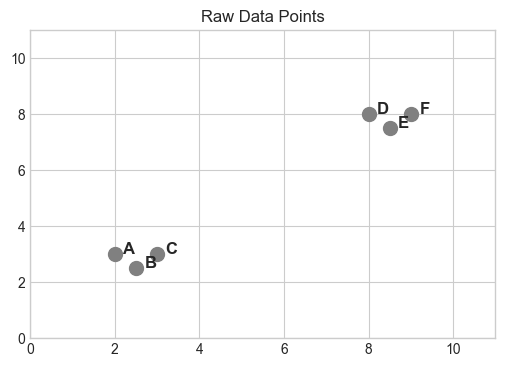

In [2]:
# Define 6 points (X, Y coordinates)
data = np.array([
    [2.0, 3.0],  # Point A
    [2.5, 2.5],  # Point B
    [3.0, 3.0],  # Point C
    [8.0, 8.0],  # Point D
    [8.5, 7.5],  # Point E
    [9.0, 8.0]   # Point F
])

labels = ['A', 'B', 'C', 'D', 'E', 'F']
df = pd.DataFrame(data, columns=['X', 'Y'], index=labels)
display(df)

# Plot the raw data
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['Y'], color='gray', s=100)

for i, label in enumerate(labels):
    plt.annotate(label, (df['X'][i] + 0.2, df['Y'][i]), fontsize=12, fontweight='bold')

plt.title('Raw Data Points')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.show()

## Step 2: Initialize Centroids ($K=2$)
Let's choose $K=2$ clusters. We need to start by guessing where the center of these clusters might be.
To make the math easy to follow, let's manually place our initial centroids at $(2, 2)$ and $(7, 7)$.

Initial Centroid 1: [2. 2.]
Initial Centroid 2: [7. 7.]


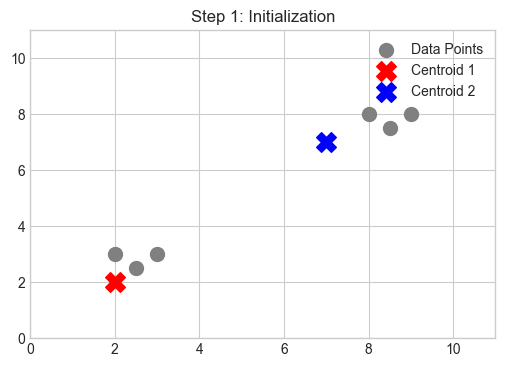

In [3]:
# Initial guess for 2 centroids
c1 = np.array([2.0, 2.0])
c2 = np.array([7.0, 7.0])

print(f"Initial Centroid 1: {c1}")
print(f"Initial Centroid 2: {c2}")

# Let's plot the points AND our initial centroids
plt.figure(figsize=(6, 4))
plt.scatter(df['X'], df['Y'], color='gray', s=100, label='Data Points')
plt.scatter(c1[0], c1[1], color='red', marker='X', s=200, label='Centroid 1')
plt.scatter(c2[0], c2[1], color='blue', marker='X', s=200, label='Centroid 2')

plt.title('Step 1: Initialization')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.legend()
plt.show()

## Step 3: Assignment (Calculate Distances)
Now we calculate the Euclidean distance from every point to both Centroid 1 and Centroid 2.
The formula for Euclidean distance between point $P(x_1, y_1)$ and centroid $C(x_2, y_2)$ is:
$$ Distance = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} $$

In [4]:
def calculate_distance(point, centroid):
    return np.sqrt(np.sum((point - centroid)**2))

# Calculate distances for all points
dist_to_c1 = [calculate_distance(row, c1) for row in data]
dist_to_c2 = [calculate_distance(row, c2) for row in data]

# Determine the closest centroid (0 for C1, 1 for C2)
assignments = [1 if d2 < d1 else 0 for d1, d2 in zip(dist_to_c1, dist_to_c2)]

df['Dist_to_C1'] = np.round(dist_to_c1, 2)
df['Dist_to_C2'] = np.round(dist_to_c2, 2)
df['Assigned_Cluster'] = assignments

print("Distance and Assignment Table (Iteration 1):")
display(df)

Distance and Assignment Table (Iteration 1):


,X,Y,Dist_to_C1,Dist_to_C2,Assigned_Cluster
A,2.0,3.0,1.00,6.40,0
B,2.5,2.5,0.71,6.36,0
C,3.0,3.0,1.41,5.66,0
D,8.0,8.0,8.49,1.41,1
E,8.5,7.5,8.51,1.58,1
F,9.0,8.0,9.22,2.24,1


### 🧠 Exercise Checkpoint
Look at the table above. Points A, B, and C are closer to Centroid 1 (Red). Points D, E, and F are closer to Centroid 2 (Blue). 
The algorithm has formed its first clusters!

## Step 4: Update the Centroids
The initial centroids were just guesses. Now that we have points assigned to them, we calculate the **mean (average) X and Y coordinates** for each cluster to find the *true* center of the group.

Old Centroid 1: [2. 2.] -> New Centroid 1: [2.5  2.83]
Old Centroid 2: [7. 7.] -> New Centroid 2: [8.5  7.83]


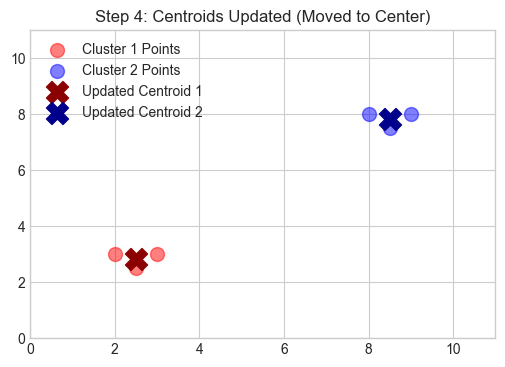

In [5]:
# Filter points by cluster
cluster_0_points = df[df['Assigned_Cluster'] == 0][['X', 'Y']].values
cluster_1_points = df[df['Assigned_Cluster'] == 1][['X', 'Y']].values

# Calculate new means
new_c1 = np.mean(cluster_0_points, axis=0)
new_c2 = np.mean(cluster_1_points, axis=0)

print(f"Old Centroid 1: {c1} -> New Centroid 1: {np.round(new_c1, 2)}")
print(f"Old Centroid 2: {c2} -> New Centroid 2: {np.round(new_c2, 2)}")

# Plot the updated centroids
plt.figure(figsize=(6, 4))
plt.scatter(cluster_0_points[:,0], cluster_0_points[:,1], color='red', s=100, alpha=0.5, label='Cluster 1 Points')
plt.scatter(cluster_1_points[:,0], cluster_1_points[:,1], color='blue', s=100, alpha=0.5, label='Cluster 2 Points')

plt.scatter(new_c1[0], new_c1[1], color='darkred', marker='X', s=250, label='Updated Centroid 1')
plt.scatter(new_c2[0], new_c2[1], color='darkblue', marker='X', s=250, label='Updated Centroid 2')

plt.title('Step 4: Centroids Updated (Moved to Center)')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.legend()
plt.show()

Notice how the "X" marks moved? In a real algorithm, this loop (Assign -> Update -> Assign -> Update) runs until the "X" marks completely stop moving. Because our data is very simple, it converged in just one step!

## Step 5: Doing it the Production Way (scikit-learn)
In the real world, we do not calculate this loop manually. We use `scikit-learn`.

Final Scikit-Learn Centroids:
 [[2.5  2.83]
 [8.5  7.83]]


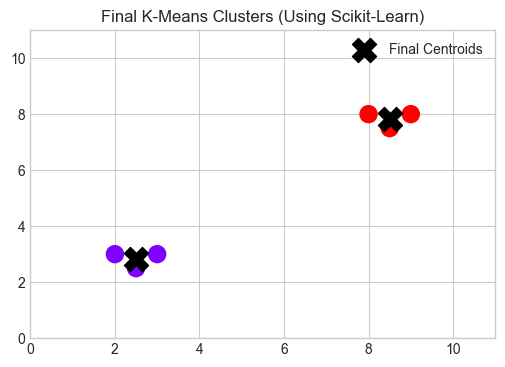

In [6]:
# Initialize the model with K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit the model to our raw data (ignore the manual steps above)
kmeans.fit(data)

# Extract the results
final_labels = kmeans.labels_
final_centroids = kmeans.cluster_centers_

print("Final Scikit-Learn Centroids:\n", np.round(final_centroids, 2))

# Plot the final production result
plt.figure(figsize=(6, 4))
scatter = plt.scatter(data[:, 0], data[:, 1], c=final_labels, cmap='rainbow', s=150)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], color='black', marker='X', s=300, label='Final Centroids')

plt.title('Final K-Means Clusters (Using Scikit-Learn)')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.legend()
plt.show()

### 🎉 Conclusion
Congratulations! You have successfully learned how K-Means clustering uses math under the hood to find group centers.
Unlike Hierarchical clustering which builds a tree (Dendrogram), K-Means creates strict boundaries based on distance to a central point.